# Multi-species UCE inference — marmoset BICAN basal ganglia

Loads `KuanP/uce-multispecies-2025-11-08` and the bundled `gene_mapping.json` from HF Hub, runs cell-embedding extraction on a subsampled marmoset dataset, then plots a UMAP of the embeddings coloured by curated cell-type labels.

Dataset: `Marmoset_HMBA_basalganglia_AIT_pre-print.h5ad` (313,033 cells × 35,787 genes). Subsampled to 5,000 cells for a quick verification run; bump `MAX_CELLS` to do the whole thing.

In [1]:
H5AD_PATH    = "/data/kuan/brain_dataset/Marmoset_HMBA_basalganglia_AIT_pre-print.h5ad"
HF_REPO      = "KuanP/uce-multispecies-2025-11-08"
SPECIES      = "callithrix_jacchus"   # JSON key for marmoset
MAX_CELLS    = 5000                    # set to None for full dataset
BATCH_SIZE   = 16
NUM_WORKERS  = 4
SUBSAMPLE_SEED = 0

In [2]:
import numpy as np
import scanpy as sc
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

from uce_brain.model import UCEForExpressionPrediction
from uce_brain.data import H5ADDataset, UCEDataCollator, load_gene_mapping, read_h5ad_subsampled

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [3]:
model = UCEForExpressionPrediction.from_pretrained(HF_REPO).eval().to(device)
vocab_path = hf_hub_download(HF_REPO, 'gene_mapping.json')
gene_mapping = load_gene_mapping(vocab_path)
print('vocab species:', sorted(gene_mapping.keys()))
print(f'vocab_size={model.config.vocab_size}  d_model={model.config.d_model}  layers={model.config.num_layers}')

2026-05-26 14:17:54,955 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/KuanP/uce-multispecies-2025-11-08/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


2026-05-26 14:17:54,969 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/KuanP/uce-multispecies-2025-11-08/45d49578730c55e879f47a932ff3b3a4080b6713/config.json "HTTP/1.1 200 OK"


2026-05-26 14:17:55,098 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/KuanP/uce-multispecies-2025-11-08/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/118 [00:00<?, ?it/s]

2026-05-26 14:18:02,260 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/KuanP/uce-multispecies-2025-11-08/resolve/main/gene_mapping.json "HTTP/1.1 302 Found"


2026-05-26 14:18:02,265 - uce_brain.data.dataset - INFO - Loading gene mapping from /home/kuan/.cache/huggingface/hub/models--KuanP--uce-multispecies-2025-11-08/snapshots/45d49578730c55e879f47a932ff3b3a4080b6713/gene_mapping.json


2026-05-26 14:18:02,403 - uce_brain.data.dataset - INFO - Top-level species keys: ['callithrix_jacchus', 'frog', 'human', 'macaca_fascicularis', 'macaca_mulatta', 'mouse', 'mouse_lemur', 'pan_troglodytes', 'pig', 'zebrafish']


vocab species: ['callithrix_jacchus', 'frog', 'human', 'macaca_fascicularis', 'macaca_mulatta', 'mouse', 'mouse_lemur', 'pan_troglodytes', 'pig', 'zebrafish']
vocab_size=178331  d_model=512  layers=8


In [4]:
# Sparse-aware sub-row read: pulls only the cells we need
# (~10x faster than sc.read_h5ad() for small subsamples; about 6x faster on the 30 GB marmoset file at 5000 cells).
if MAX_CELLS is None:
    adata = sc.read_h5ad(H5AD_PATH)   # full file; ~4 min for marmoset
else:
    adata = read_h5ad_subsampled(H5AD_PATH, n_cells=MAX_CELLS, seed=SUBSAMPLE_SEED)
print('shape:', adata.shape, '  X type:', type(adata.X).__name__)
print(
    'obs label columns:',
    [c for c in ('Neighborhood','Class','Subclass','Group','cell_type_ontology_term',
                 'final_identity','new_identity','new_age','batch','cell_type','tissue')
     if c in adata.obs.columns],
)


2026-05-26 14:18:02,621 - uce_brain.data.h5ad_subsample - INFO - Reading 5000 / 313033 rows from /data/kuan/brain_dataset/Marmoset_HMBA_basalganglia_AIT_pre-print.h5ad


2026-05-26 14:18:43,845 - uce_brain.data.h5ad_subsample - INFO - Built AnnData: (5000, 35787), X nnz=17829789


shape: (5000, 35787)   X type: csr_matrix
obs label columns: ['Neighborhood', 'Class', 'Subclass', 'Group', 'cell_type_ontology_term']


In [5]:
dataset = H5ADDataset(
    adata,
    gene_mapping=gene_mapping,
    species=SPECIES,
    mask_prop=0.0,   # zero for inference — keep every expressed gene visible
)
collator = UCEDataCollator()
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collator,
    pin_memory=True,
)
print(f'dataset size: {len(dataset)} cells, {len(dataloader)} batches of {BATCH_SIZE}')
print(f'gene overlap: {len(dataset.aligned_gene_names)} / {adata.n_vars} h5ad genes mapped to vocab[{SPECIES}]')

2026-05-26 14:18:43,857 - uce_brain.data.dataset - INFO - Loading AnnData object with shape (5000, 35787)


2026-05-26 14:18:43,858 - uce_brain.data.dataset - INFO - Loaded 5000 cells with 35787 genes


2026-05-26 14:18:43,859 - uce_brain.data.dataset - INFO - Using var_names as gene names (already gene symbols)


2026-05-26 14:18:43,859 - uce_brain.data.dataset - INFO - Aligning h5ad genes to gene mapping...


2026-05-26 14:18:43,865 - uce_brain.data.dataset - INFO -   H5AD genes: 35787


2026-05-26 14:18:43,865 - uce_brain.data.dataset - INFO -   Gene mapping vocabulary: 15376


2026-05-26 14:18:43,866 - uce_brain.data.dataset - INFO -   Genes in common: 14723


dataset size: 5000 cells, 313 batches of 16
gene overlap: 14723 / 35787 h5ad genes mapped to vocab[callithrix_jacchus]


In [6]:
embeddings = np.empty((len(dataset), model.config.output_embedding_dim), dtype=np.float32)
ptr = 0
with torch.inference_mode():
    for batch in tqdm(dataloader, desc='extracting embeddings'):
        out = model.extract_cell_embeddings(
            input_ids=batch['input_ids'].to(device, non_blocking=True),
            attention_mask=batch['attention_mask'].to(device, non_blocking=True),
        )
        emb = out.cell_embedding.float().cpu().numpy()
        embeddings[ptr:ptr+emb.shape[0]] = emb
        ptr += emb.shape[0]
print('embeddings:', embeddings.shape, 'finite:', np.isfinite(embeddings).all())

extracting embeddings:   0%|          | 0/313 [00:00<?, ?it/s]

/home/kuan/dev-multi-species/data_collection_exp/uce-brain/UCE-brain/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


embeddings: (5000, 512) finite: True


In [7]:
# Attach embeddings as an obsm matrix for downstream scanpy ops.
adata.obsm['X_uce'] = embeddings

In [8]:
# Build kNN + UMAP on the UCE embedding. Quick sanity check that the
# embedding separates known cell-type labels.
sc.pp.neighbors(adata, use_rep='X_uce', n_neighbors=15)
sc.tl.umap(adata, min_dist=0.3)

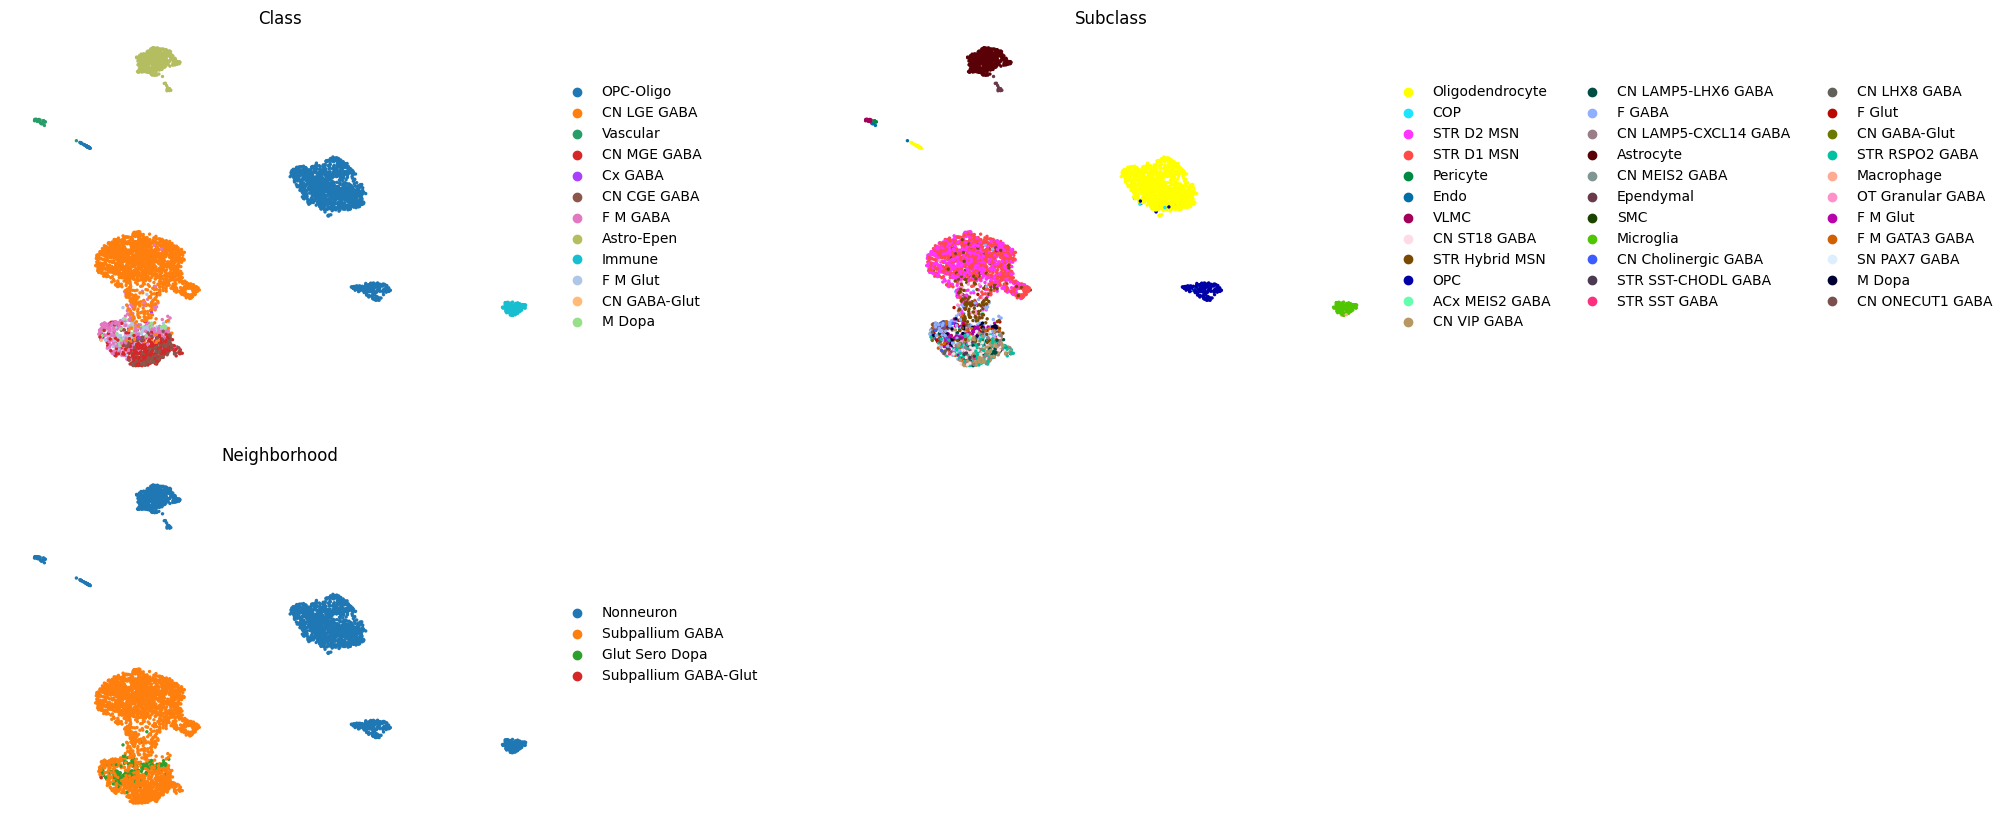

In [9]:
import matplotlib.pyplot as plt
color_keys = [c for c in ('Class', 'Subclass', 'Neighborhood') if c in adata.obs.columns]
if color_keys:
    sc.pl.umap(adata, color=color_keys, ncols=2, frameon=False, wspace=0.4)
else:
    sc.pl.umap(adata, frameon=False)
    print('no curated label columns found; plotted unlabeled UMAP only')